# Importing Libraries and Loading Dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Advertising.csv')

# Display the first 5 rows of the DataFrame
display(df.head(5))

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Data Exploration and Cleaning

In [12]:
# Drop the 'Unnamed: 0' column
df = df.drop('Unnamed: 0', axis=1)

print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Descriptive Statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


# Exploratory Data Analysis (EDA)

## Scatter plot

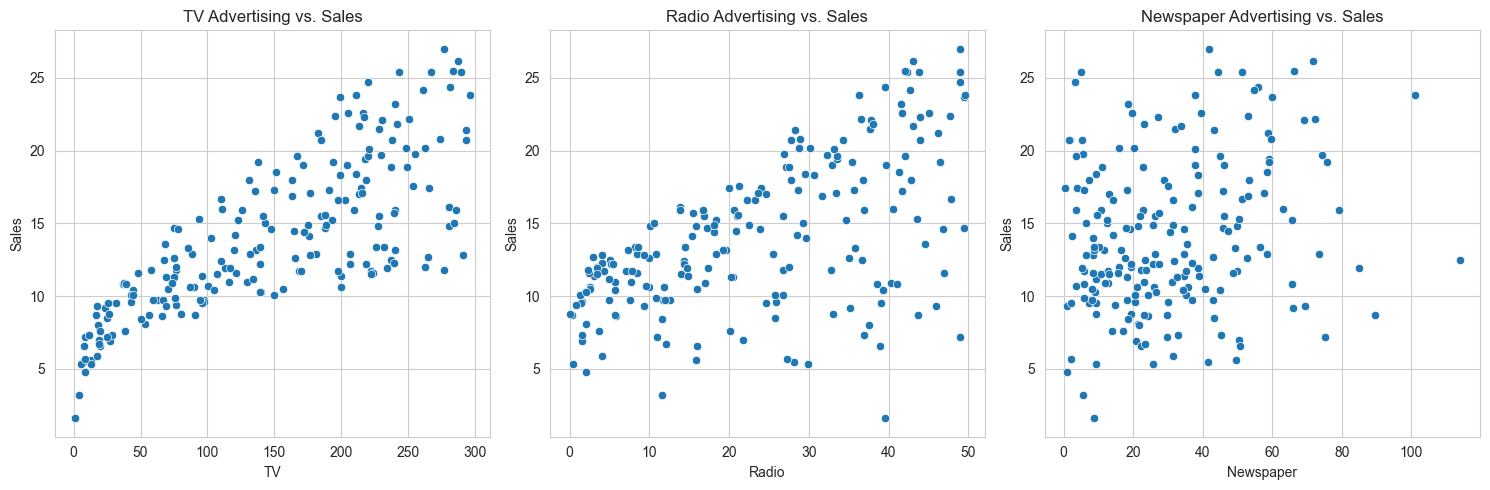

In [13]:
sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))

# Scatter plot for TV vs Sales
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs. Sales')

# Scatter plot for Radio vs Sales
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs. Sales')

# Scatter plot for Newspaper vs Sales
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Newspaper Advertising vs. Sales')

plt.tight_layout()
plt.show()

## Histogram with KDE

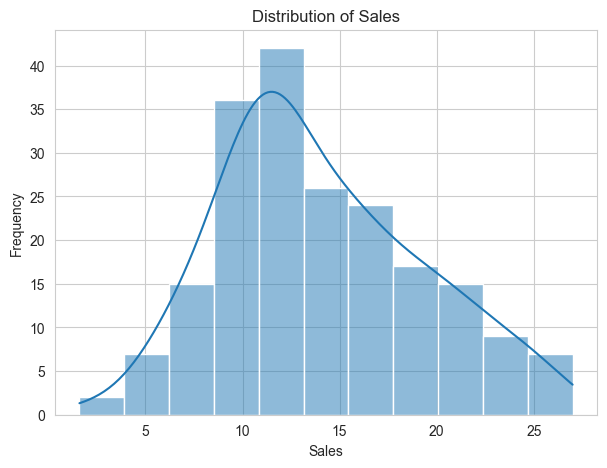

In [14]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

## Pair Plot

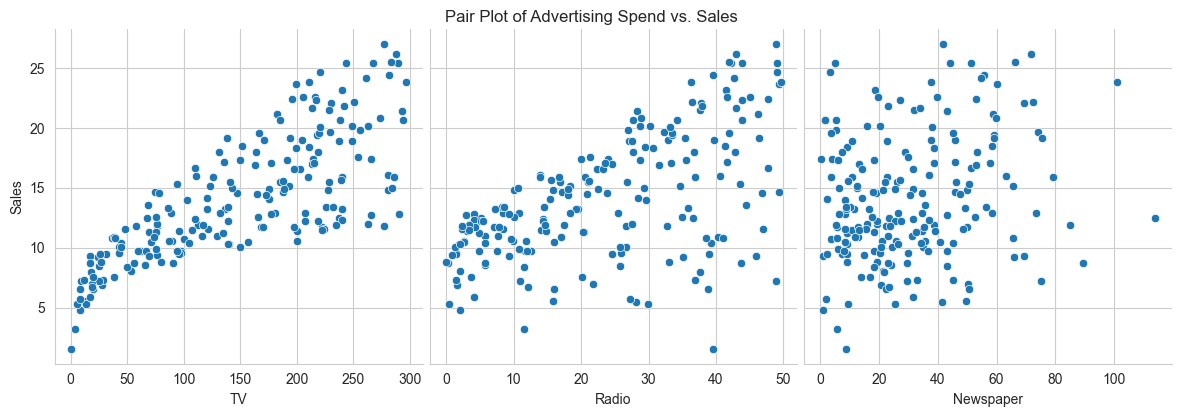

In [15]:
# Pairplot to visualize relationships between all variables
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle('Pair Plot of Advertising Spend vs. Sales', y=1.02)
plt.show()

## Feature Selection and Train-Test Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


## Model Training

In [17]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Linear Regression model trained successfully!
Model Coefficients: [0.04472952 0.18919505 0.00276111]
Model Intercept: 2.979067338122629


## Model Evaluation

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared: 0.8994
Mean Squared Error (MSE): 3.1741


## Visualizing Model Predictions

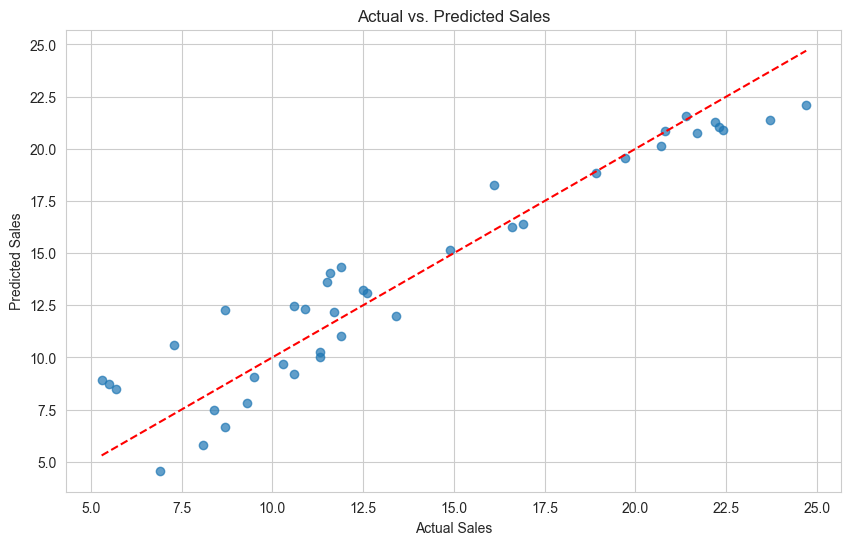

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.grid(True)
plt.show()

## Model Coefficients

,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761



Interpretation of Coefficients:
A positive coefficient indicates that as the advertising spend in that channel increases, sales tend to increase (assuming other factors remain constant).
A negative coefficient indicates an inverse relationship. The magnitude of the coefficient suggests the strength of this relationship.


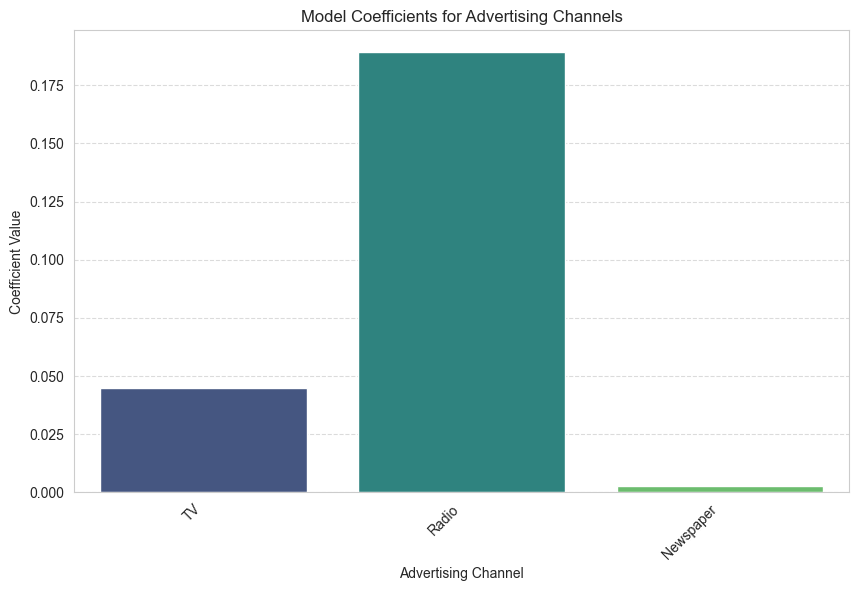

In [20]:
feature_names = X.columns
coefficients = model.coef_

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
display(coeff_df.sort_values(by='Coefficient', ascending=False))

print("\nInterpretation of Coefficients:")
print("A positive coefficient indicates that as the advertising spend in that channel increases, sales tend to increase (assuming other factors remain constant).")
print("A negative coefficient indicates an inverse relationship. The magnitude of the coefficient suggests the strength of this relationship.")
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coeff_df, palette='viridis', hue='Feature', legend=False)
plt.title('Model Coefficients for Advertising Channels')
plt.xlabel('Advertising Channel')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Insights

TV advertising has the highest impact on sales growth.

Radio advertising shows a moderate effect on sales.

Newspaper advertising has a lower influence compared to other channels.

Optimizing advertising budget can improve sales performance and marketing decisions.